# #30DayMapChallenge - Día 11: Ártico / Antártico
## Caso de Negocio: Rutas globales y la mentira del Mercator

**Autor:** Mario Ignacio Ibañez Castro | **Rol:** Data Scientist & Strategic Planner

### El objetivo
En logística global, el mapa que uses **cambia la decisión**. Mercator infla los polos y esconde el atajo ártico. Hoy comparamos:

1. Ruta Europa–Asia vía **Suez**
2. **Northern Sea Route** (Ártico)
3. Cadena de suministro científica hacia **Antártida**

…en proyecciones polares (EPSG:3995 / EPSG:3031) vs Web Mercator.

**Pregunta de negocio:** ¿Cuánto “acorta” el Ártico frente a Suez — y por qué Mercator no te deja verlo bien?

**Reto técnico:** Proyecciones polares y manejo de distorsión.

**Fuente:** [Natural Earth](https://www.naturalearthdata.com/) 110m + geodésicas WGS84 (pyproj).

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.style.use('dark_background')
%matplotlib inline

RUTA = Path('../00_Datos')
OUT = Path('.')

land = gpd.read_file(next((RUTA/'ne_110m_land').glob('*.shp')))
coast = gpd.read_file(next((RUTA/'ne_110m_coastline').glob('*.shp')))
grat = gpd.read_file(next((RUTA/'ne_110m_graticules_30').glob('*.shp')))
rutas = gpd.read_file(RUTA/'rutas_globales.geojson')
resumen = pd.read_csv(RUTA/'rutas_globales_resumen.csv')

display(resumen)
km_suez = float(resumen.loc[resumen['polo']=='ninguno','km'].iloc[0])
km_arc = float(resumen.loc[resumen['polo']=='artico','km'].iloc[0])
ahorro = (km_suez - km_arc) / km_suez * 100
print(f'Ahorro NSR vs Suez: {ahorro:.1f}% ({km_suez-km_arc:.0f} km)')

,ruta,tipo,polo,km
0,Suez (tradicional),comercio_europa_asia,ninguno,18612.148474
1,Northern Sea Route (Ártico),comercio_europa_asia,artico,13376.369398
2,Punta Arenas → McMurdo (Antártida),logistica_cientifica,antartico,4951.613609


Ahorro NSR vs Suez: 28.1% (5236 km)


### 1. El sesgo de Mercator
Web Mercator (EPSG:3857) es el default de casi todo dashboard. En polos **rompe** formas y distancias: Groenlandia parece un continente, el Ártico se estira y las rutas polares se ven “raras”.

/home/mibanez/Documentos/Proyectos/30daysMapsChallenge/30DaysMapChallenge/.venv/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


/home/mibanez/Documentos/Proyectos/30daysMapsChallenge/30DaysMapChallenge/.venv/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


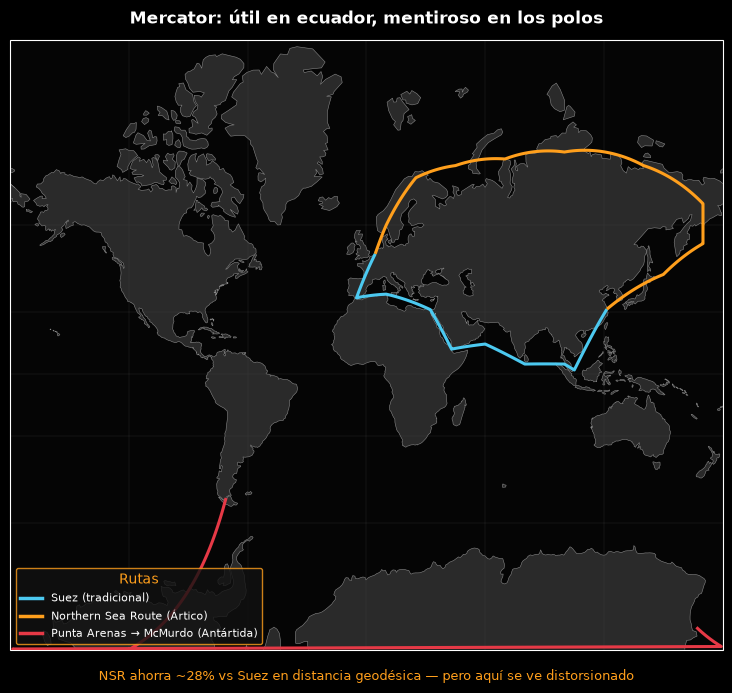

Guardado: Dia11_Mercator_Rutas.png


In [2]:
COLORS = {
    'Suez (tradicional)': '#4CC9F0',
    'Northern Sea Route (Ártico)': '#FF9F1C',
    'Punta Arenas → McMurdo (Antártida)': '#E63946',
}

fig = plt.figure(figsize=(14, 7))
fig.patch.set_facecolor('black')
ax = plt.axes(projection=ccrs.Mercator())
ax.set_global()
ax.set_facecolor('#050505')
ax.add_feature(cfeature.LAND, facecolor='#2a2a2a', edgecolor='none', zorder=1)
ax.add_feature(cfeature.COASTLINE, edgecolor='#888', linewidth=0.4, zorder=2)
ax.gridlines(draw_labels=False, linewidth=0.3, color='#444', alpha=0.6)

for _, row in rutas.iterrows():
    ax.add_geometries(
        [row.geometry],
        crs=ccrs.PlateCarree(),
        facecolor='none',
        edgecolor=COLORS[row['ruta']],
        linewidth=2.2,
        zorder=3,
    )

handles = [Line2D([0],[0], color=c, lw=2.5, label=n) for n,c in COLORS.items()]
leg = ax.legend(handles=handles, loc='lower left', facecolor='#111', edgecolor='#FF9F1C',
                labelcolor='white', fontsize=8, title='Rutas')
leg.get_title().set_color('#FF9F1C')
ax.set_title('Mercator: útil en ecuador, mentiroso en los polos', color='white', fontweight='bold', pad=12)
ax.text(0.5, -0.05, f'NSR ahorra ~{ahorro:.0f}% vs Suez en distancia geodésica — pero aquí se ve distorsionado',
        transform=ax.transAxes, ha='center', color='#FF9F1C', fontsize=9)
plt.tight_layout()
plt.savefig(OUT/'Dia11_Mercator_Rutas.png', dpi=170, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia11_Mercator_Rutas.png')

### 2. Proyección polar ártica (EPSG:3995 / North Polar Stereo)
Aquí el Polo Norte es el centro. La Northern Sea Route deja de ser un arco “raro” y se lee como corredor logístico.

/home/mibanez/Documentos/Proyectos/30daysMapsChallenge/30DaysMapChallenge/.venv/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


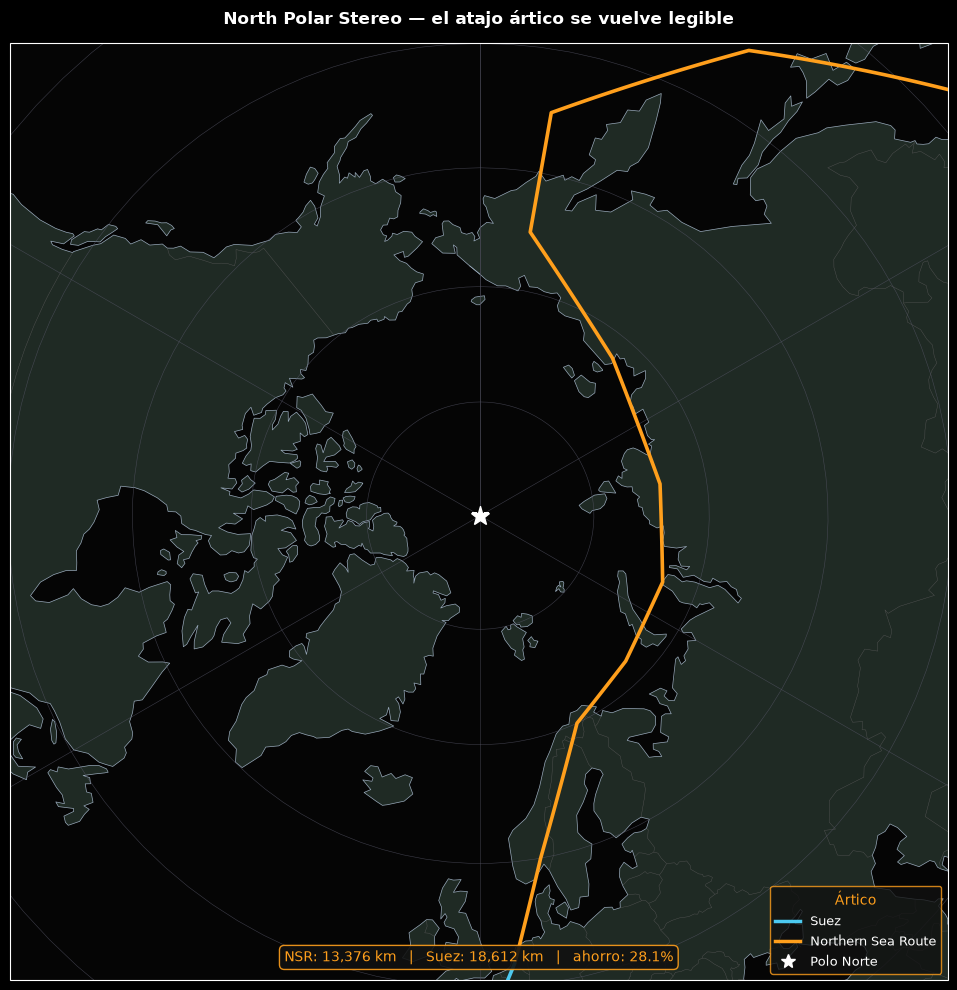

Guardado: Dia11_Artico_Polar.png


In [3]:
fig = plt.figure(figsize=(10, 10))
fig.patch.set_facecolor('black')
ax = plt.axes(projection=ccrs.NorthPolarStereo())
ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
ax.set_facecolor('#050505')
ax.add_feature(cfeature.LAND, facecolor='#1f2a24', edgecolor='none', zorder=1)
ax.add_feature(cfeature.COASTLINE, edgecolor='#9ab', linewidth=0.5, zorder=2)
ax.add_feature(cfeature.BORDERS, edgecolor='#555', linewidth=0.3, zorder=2)
gl = ax.gridlines(draw_labels=False, linewidth=0.4, color='#556', alpha=0.7)

# Solo rutas relevantes al Ártico / comercio
for _, row in rutas.iterrows():
    if row['polo'] == 'antartico':
        continue
    ax.add_geometries(
        [row.geometry],
        crs=ccrs.PlateCarree(),
        facecolor='none',
        edgecolor=COLORS[row['ruta']],
        linewidth=2.6,
        zorder=3,
    )

# Polo
ax.plot(0, 90, marker='*', markersize=14, color='white', transform=ccrs.PlateCarree(), zorder=4)

handles = [
    Line2D([0],[0], color=COLORS['Suez (tradicional)'], lw=2.5, label='Suez'),
    Line2D([0],[0], color=COLORS['Northern Sea Route (Ártico)'], lw=2.5, label='Northern Sea Route'),
    Line2D([0],[0], marker='*', color='white', lw=0, markersize=10, label='Polo Norte'),
]
leg = ax.legend(handles=handles, loc='lower right', facecolor='#111', edgecolor='#FF9F1C',
                labelcolor='white', fontsize=9, title='Ártico')
leg.get_title().set_color('#FF9F1C')
ax.set_title('North Polar Stereo — el atajo ártico se vuelve legible', color='white', fontweight='bold', pad=14)
ax.text(0.5, 0.02, f'NSR: {km_arc:,.0f} km   |   Suez: {km_suez:,.0f} km   |   ahorro: {ahorro:.1f}%',
        transform=ax.transAxes, ha='center', color='#FF9F1C', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#111', edgecolor='#FF9F1C', alpha=0.9))
plt.tight_layout()
plt.savefig(OUT/'Dia11_Artico_Polar.png', dpi=180, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia11_Artico_Polar.png')

### 3. Proyección polar antártica (EPSG:3031 / South Polar Stereo)
Misma lógica en el otro polo: la ruta de reabastecimiento científico deja de ser un cordel vertical en Mercator.

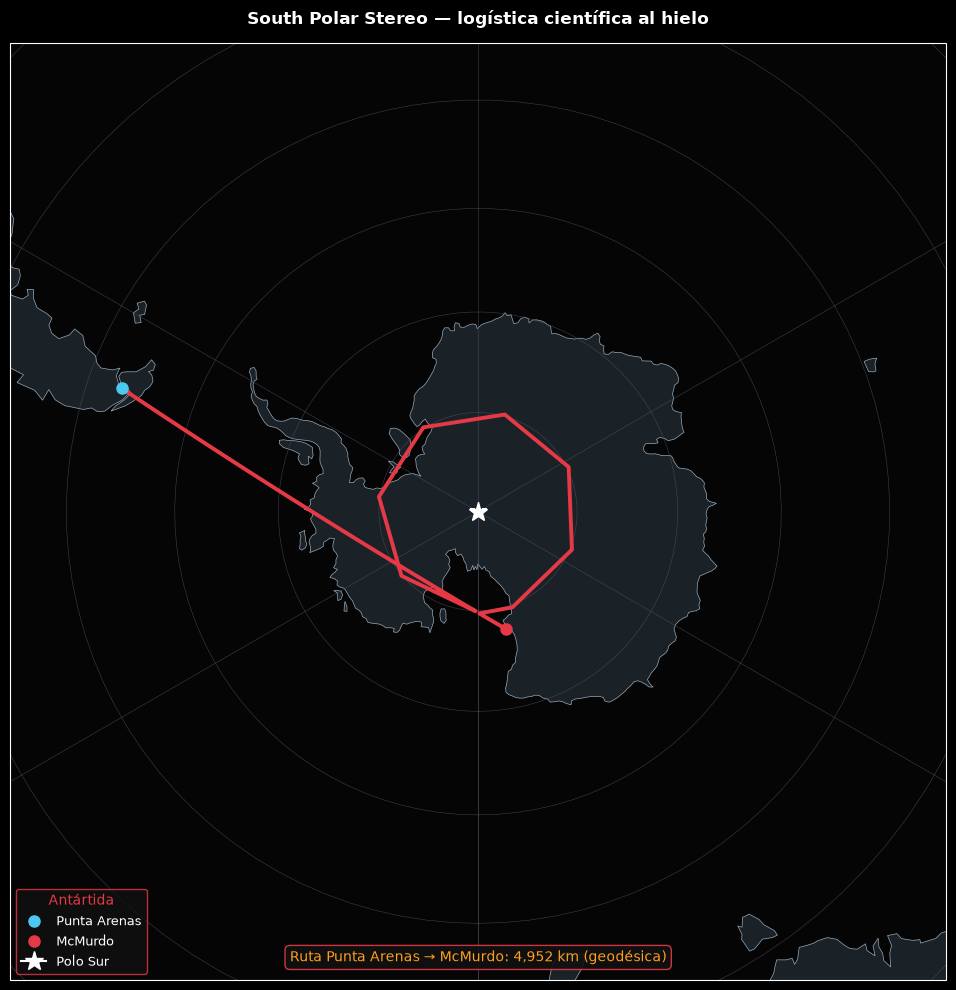

Guardado: Dia11_Antartico_Polar.png


In [4]:
fig = plt.figure(figsize=(10, 10))
fig.patch.set_facecolor('black')
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -45], crs=ccrs.PlateCarree())
ax.set_facecolor('#050505')
ax.add_feature(cfeature.LAND, facecolor='#1a2228', edgecolor='none', zorder=1)
ax.add_feature(cfeature.COASTLINE, edgecolor='#9ab', linewidth=0.5, zorder=2)
ax.gridlines(draw_labels=False, linewidth=0.4, color='#556', alpha=0.7)

ant = rutas[rutas['polo']=='antartico'].iloc[0]
ax.add_geometries([ant.geometry], crs=ccrs.PlateCarree(), facecolor='none',
                  edgecolor=COLORS[ant['ruta']], linewidth=2.8, zorder=3)
# endpoints
ax.plot(-70.91, -53.16, 'o', color='#4CC9F0', markersize=8, transform=ccrs.PlateCarree(), zorder=4, label='Punta Arenas')
ax.plot(166.67, -77.85, 'o', color='#E63946', markersize=8, transform=ccrs.PlateCarree(), zorder=4, label='McMurdo')
ax.plot(0, -90, marker='*', markersize=14, color='white', transform=ccrs.PlateCarree(), zorder=4, label='Polo Sur')

leg = ax.legend(loc='lower left', facecolor='#111', edgecolor='#E63946', labelcolor='white', fontsize=9, title='Antártida')
leg.get_title().set_color('#E63946')
ax.set_title('South Polar Stereo — logística científica al hielo', color='white', fontweight='bold', pad=14)
ax.text(0.5, 0.02, f"Ruta Punta Arenas → McMurdo: {ant['km']:,.0f} km (geodésica)",
        transform=ax.transAxes, ha='center', color='#FF9F1C', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#111', edgecolor='#E63946', alpha=0.9))
plt.tight_layout()
plt.savefig(OUT/'Dia11_Antartico_Polar.png', dpi=180, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia11_Antartico_Polar.png')

### 4. Comparativa de distorsión (panel)
Misma Tierra, tres “lentes”. El KPI de negocio (km) es geodésico; la proyección solo debe **comunicarlo** sin mentir visualmente.

/home/mibanez/Documentos/Proyectos/30daysMapsChallenge/30DaysMapChallenge/.venv/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


/home/mibanez/Documentos/Proyectos/30daysMapsChallenge/30DaysMapChallenge/.venv/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


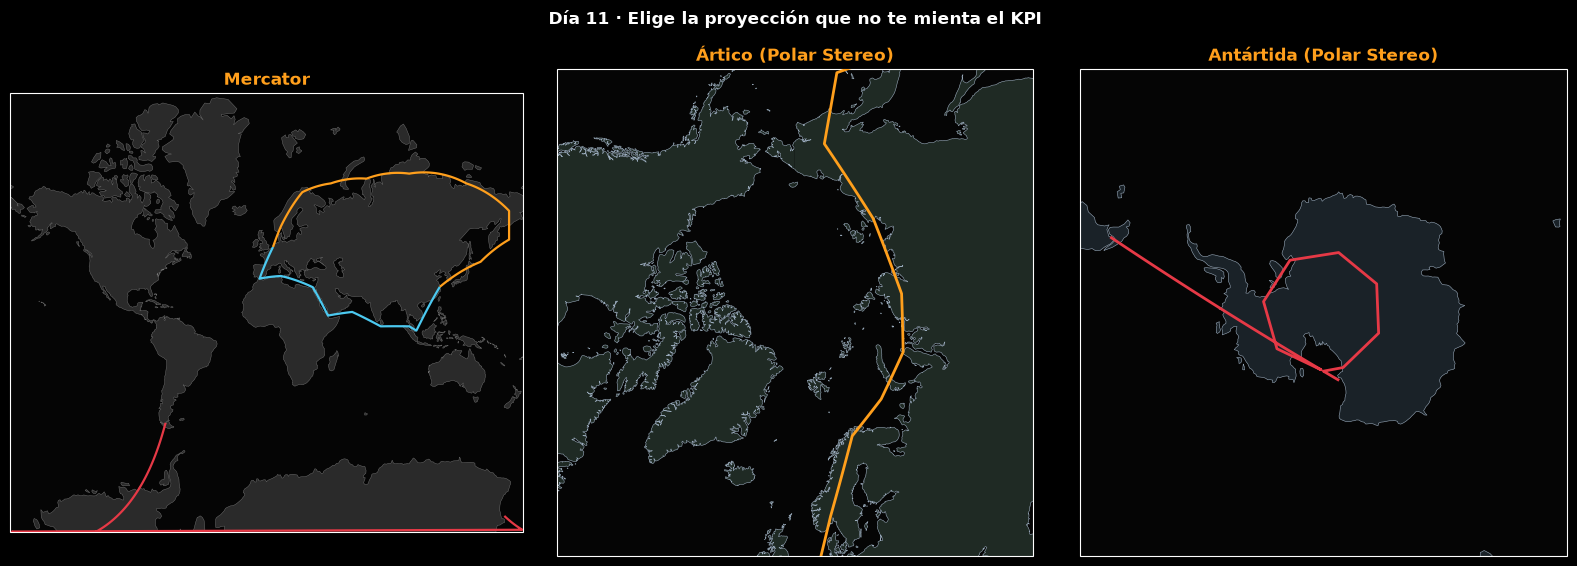

Guardado: Dia11_Panel_Proyecciones.png


In [5]:
fig = plt.figure(figsize=(16, 5.5))
fig.patch.set_facecolor('black')

# Mercator crop high latitudes look weird — show global
ax1 = fig.add_subplot(1, 3, 1, projection=ccrs.Mercator())
ax1.set_global(); ax1.set_facecolor('#050505')
ax1.add_feature(cfeature.LAND, facecolor='#2a2a2a', zorder=1)
ax1.add_feature(cfeature.COASTLINE, edgecolor='#777', linewidth=0.3, zorder=2)
for _, row in rutas.iterrows():
    ax1.add_geometries([row.geometry], crs=ccrs.PlateCarree(), facecolor='none',
                       edgecolor=COLORS[row['ruta']], linewidth=1.6, zorder=3)
ax1.set_title('Mercator', color='#FF9F1C', fontweight='bold')

ax2 = fig.add_subplot(1, 3, 2, projection=ccrs.NorthPolarStereo())
ax2.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree()); ax2.set_facecolor('#050505')
ax2.add_feature(cfeature.LAND, facecolor='#1f2a24', zorder=1)
ax2.add_feature(cfeature.COASTLINE, edgecolor='#9ab', linewidth=0.4, zorder=2)
for _, row in rutas[rutas['polo']!='antartico'].iterrows():
    ax2.add_geometries([row.geometry], crs=ccrs.PlateCarree(), facecolor='none',
                       edgecolor=COLORS[row['ruta']], linewidth=2.0, zorder=3)
ax2.set_title('Ártico (Polar Stereo)', color='#FF9F1C', fontweight='bold')

ax3 = fig.add_subplot(1, 3, 3, projection=ccrs.SouthPolarStereo())
ax3.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree()); ax3.set_facecolor('#050505')
ax3.add_feature(cfeature.LAND, facecolor='#1a2228', zorder=1)
ax3.add_feature(cfeature.COASTLINE, edgecolor='#9ab', linewidth=0.4, zorder=2)
ax3.add_geometries([ant.geometry], crs=ccrs.PlateCarree(), facecolor='none',
                   edgecolor=COLORS[ant['ruta']], linewidth=2.0, zorder=3)
ax3.set_title('Antártida (Polar Stereo)', color='#FF9F1C', fontweight='bold')

fig.suptitle('Día 11 · Elige la proyección que no te mienta el KPI', color='white', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT/'Dia11_Panel_Proyecciones.png', dpi=160, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia11_Panel_Proyecciones.png')

### 5. Insight de negocio
- **Calcular** distancias siempre en geodésica (WGS84), nunca midiendo píxeles en Mercator.
- **Visualizar** rutas polares en Polar Stereographic (o Azimutal Equidistante centrada en el polo).
- El Ártico no es solo clima: es una variable de **costo y lead time** cuando el hielo lo permite — y un riesgo geopolítico cuando no.

**Regla práctica:** si tu mapa de supply chain global usa solo Mercator, estás sesgando la conversación ejecutiva.

### Regenerar
```bash
python ../00_Datos/descargarNaturalEarth.py
python ../00_Datos/generarRutas.py
```

In [6]:
print('Día 11 completado.')
print(resumen.to_string(index=False))
print(f'Ahorro NSR vs Suez: {ahorro:.1f}%')

Día 11 completado.
                              ruta                 tipo      polo           km
                Suez (tradicional) comercio_europa_asia   ninguno 18612.148474
       Northern Sea Route (Ártico) comercio_europa_asia    artico 13376.369398
Punta Arenas → McMurdo (Antártida) logistica_cientifica antartico  4951.613609
Ahorro NSR vs Suez: 28.1%
